#Proyecto Modulo 2 TE y MD
##Integrantes del Equipo:
  Emiliano Dominguez Venegas

  Juan Antonio San Juan Retama

##Ajuste de Distribuciones para Precios de Productos

Pregunta de investigación: ¿Qué distribución (Normal, Log-Normal o Gamma) modela
mejor los precios de productos? ¿Difiere el precio medio entre categorías?

##1. Planteamiento del problema

En el comercio, los precios de los productos varían debido a diferentes factores, como la categoría a la que pertenecen, la marca, la demanda y las estrategias de venta de cada proveedor. Analizar el comportamiento de estos precios permite conocer qué distribución probabilística representa mejor los datos y facilita el análisis estadístico más confiable.


En este proyecto se estudiará la distribución de los precios de un conjunto de productos de Amazon. Para ello, se ajustarán las distribuciones Normal, Log-Normal y Gamma mediante el método de Máxima Verosimilitud (MLE). Posteriormente, se comparará el ajuste de cada una para identificar cuál describe mejor los datos. Finalmente, se evaluará si existen diferencias estadísticamente significativas en el precio promedio entre las distintas categorías de productos.

##2. Objetivo general

Determinar cuál de las distribuciones Normal, Log-Normal o Gamma proporciona el mejor ajuste para modelar los precios de productos mediante estimación por máxima verosimilitud, así como evaluar si existen diferencias significativas entre los precios medios de distintas categorías.


##3. Objetivos específicos

1. Realizar un análisis exploratorio del conjunto de datos.

2. Estimar los parámetros de las distribuciones Normal, Log-Normal y Gamma mediante el método de Máxima Verosimilitud (MLE).

3. Comparar el ajuste de cada distribución utilizando criterios estadísticos y representaciones gráficas.

4. Construir un intervalo de confianza del 95% para el precio promedio de los productos.

5. Realizar una prueba de hipótesis para evaluar si existen diferencias estadísticamente significativas en el precio promedio entre las distintas categorías de productos.

6. Interpretar los resultados obtenidos para identificar cuál de las distribuciones describe mejor el comportamiento de los precios.

In [ ]:
###Descargamos los datos desde kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lokeshparab/amazon-products-dataset")

print("Path to dataset files:", path)

100%|██████████| 79.7M/79.7M [00:04<00:00, 17.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lokeshparab/amazon-products-dataset/versions/2


In [ ]:
#Revisamos los archivos que descargamos.
import os

os.listdir(path)

['Washing Machines.csv',
 'Car Parts.csv',
 'All Home and Kitchen.csv',
 'Rucksacks.csv',
 'Gold and Diamond Jewellery.csv',
 'Indian Classical.csv',
 'Cricket.csv',
 'Gaming Accessories.csv',
 'Camping and Hiking.csv',
 'All Music.csv',
 'Diapers.csv',
 'Kids Watches.csv',
 'Car and Bike Care.csv',
 'Travel Duffles.csv',
 'Motorbike Accessories and Parts.csv',
 'All Sports Fitness and Outdoors.csv',
 'Badminton.csv',
 'Jeans.csv',
 'Exam Central.csv',
 'Furniture.csv',
 'Snack Foods.csv',
 'Personal Care Appliances.csv',
 'Shirts.csv',
 'Fashion and Silver Jewellery.csv',
 'Cycling.csv',
 'Jewellery.csv',
 'Cardio Equipment.csv',
 'Test Measure and Inspect.csv',
 'Janitorial and Sanitation Supplies.csv',
 'Kindle eBooks.csv',
 'All Grocery and Gourmet Foods.csv',
 'Home Audio and Theater.csv',
 'Kids Fashion.csv',
 'Home Furnishing.csv',
 'Fiction Books.csv',
 'Home Storage.csv',
 'Entertainment Collectibles.csv',
 'Travel Accessories.csv',
 'Wallets.csv',
 'Sportswear.csv',
 'Blu-ray

In [ ]:
#Importamos Pandas


import os
import pandas as pd


# Creamos listas con los siguientes archivos

archivos = [
    "Sports Shoes.csv",
    "Running.csv",
    "Casual Shoes.csv"
]

for archivo in archivos:

#Creamos un dataframe para guardar la informacion

    df = pd.read_csv(os.path.join(path, archivo))

# Mostramos el tamaño de los datos y vemos algunas caracteristicas de ellos.
    print(f"\n{'='*70}")
    print(f"{archivo}")
    print(f"{'='*70}")

    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")

    print("\nColumnas:")
    print(df.columns.tolist())

    print("\nPrimeras 3 filas:")
    display(df.head(3))


Sports Shoes.csv
Filas: 19200
Columnas: 9

Columnas:
['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price']

Primeras 3 filas:


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,ASIAN Men's Wonder-13 Sports Running Shoes,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/61utX8kBDl...,https://www.amazon.in/Wonder-Firozi-Sports-Sho...,4.0,"86,521",₹524,₹699
1,Campus Men's OXYFIT (N) Walking Shoe,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/61ePa5fEKn...,https://www.amazon.in/Campus-OXYFIT-Walking-Sh...,4.1,"30,222",₹648,₹999
2,Campus Men's Maxico Running Shoes,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/81Pk4RiSKq...,https://www.amazon.in/Campus-Maxico-MODBLU-BLU...,3.9,"20,422",₹675,"₹1,299"



Running.csv
Filas: 912
Columnas: 9

Columnas:
['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price']

Primeras 3 filas:


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,Amazon Brand - Symactive Men's Regular Fit T-S...,sports & fitness,Running,https://m.media-amazon.com/images/I/7148IlzWBV...,https://www.amazon.in/Amazon-Brand-Symbol-T-Sh...,4.0,"2,908",₹309,₹999
1,Jockey Mens Slub Casual Track Pant,sports & fitness,Running,https://m.media-amazon.com/images/I/61S5skYN95...,https://www.amazon.in/Jockey-Cotton-Track-9510...,4.1,"5,550","₹1,186","₹1,399"
2,ASIAN Men's Skypee-162 Casual Sneaker Lightwei...,sports & fitness,Running,https://m.media-amazon.com/images/I/61O41FwCQF...,https://www.amazon.in/ASIAN-Skypy-162-Black-Ca...,3.8,"4,379",₹459,₹699



Casual Shoes.csv
Filas: 19056
Columnas: 9

Columnas:
['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price']

Primeras 3 filas:


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,Sparx mens Sd9039g Sneakers,men's shoes,Casual Shoes,https://m.media-amazon.com/images/I/51e48JV2Gf...,https://www.amazon.in/Sparx-Casual-Stripped-Sn...,4.0,"1,893",₹499,₹999
1,Sparx Mens Sm-439 Sneaker,men's shoes,Casual Shoes,https://m.media-amazon.com/images/I/71gVtJPjZZ...,https://www.amazon.in/Sparx-SM-439-White-Casua...,4.2,"10,388",₹594,₹699
2,crocs Unisex Adult Slate Grey/Lime Punch Bayab...,men's shoes,Casual Shoes,https://m.media-amazon.com/images/I/810I1APNbm...,https://www.amazon.in/crocs-Unisex-Adult-Bayab...,NaN,NaN,"₹3,100","₹4,495"


In [ ]:
###Empezamos a prepara los datos, creamos diccionarios y una lista vacia donde se van a agregar los productos y su categoria.

import os
import pandas as pd

# Diccionario: archivo -> categoría
archivos = {
    "Sports Shoes.csv": "Sports Shoes",
    "Running.csv": "Running",
    "Casual Shoes.csv": "Casual Shoes"
}

dfs = []

for archivo, categoria in archivos.items():

    ruta = os.path.join(path, archivo)
    df = pd.read_csv(ruta)
    df["category"] = categoria
    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)

print(f"Total de registros: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}")

df.head()

Total de registros: 39168
Total de columnas: 10


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,category
0,ASIAN Men's Wonder-13 Sports Running Shoes,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/61utX8kBDl...,https://www.amazon.in/Wonder-Firozi-Sports-Sho...,4.0,"86,521",₹524,₹699,Sports Shoes
1,Campus Men's OXYFIT (N) Walking Shoe,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/61ePa5fEKn...,https://www.amazon.in/Campus-OXYFIT-Walking-Sh...,4.1,"30,222",₹648,₹999,Sports Shoes
2,Campus Men's Maxico Running Shoes,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/81Pk4RiSKq...,https://www.amazon.in/Campus-Maxico-MODBLU-BLU...,3.9,"20,422",₹675,"₹1,299",Sports Shoes
3,Campus Men's Rodeo-2 Running Shoes,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/6138Uxu+hv...,https://www.amazon.in/Campus-Rodeo-PRO-Running...,4.0,"14,455",₹751,"₹1,299",Sports Shoes
4,Reebok Men's Energy Runner LP Nacho/Conavy/Non...,men's shoes,Sports Shoes,https://m.media-amazon.com/images/I/41dXa2CVvP...,https://www.amazon.in/Reebok-Mens-Energy-Runne...,4.0,"2,819","₹1,250","₹2,499",Sports Shoes


In [ ]:
# Eliminamos las columnas que no vamos a usar.
df.drop(columns=["image", "link"], inplace=True)
df.columns

Index(['name', 'main_category', 'sub_category', 'ratings', 'no_of_ratings',
       'discount_price', 'actual_price', 'category'],
      dtype='object')

In [ ]:
df.head(5)

,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price,category
0,ASIAN Men's Wonder-13 Sports Running Shoes,men's shoes,Sports Shoes,4.0,"86,521",₹524,₹699,Sports Shoes
1,Campus Men's OXYFIT (N) Walking Shoe,men's shoes,Sports Shoes,4.1,"30,222",₹648,₹999,Sports Shoes
2,Campus Men's Maxico Running Shoes,men's shoes,Sports Shoes,3.9,"20,422",₹675,"₹1,299",Sports Shoes
3,Campus Men's Rodeo-2 Running Shoes,men's shoes,Sports Shoes,4.0,"14,455",₹751,"₹1,299",Sports Shoes
4,Reebok Men's Energy Runner LP Nacho/Conavy/Non...,men's shoes,Sports Shoes,4.0,"2,819","₹1,250","₹2,499",Sports Shoes


In [ ]:
# Limpiar las columnas de precios
price_cols = ["discount_price", "actual_price"]

for col in price_cols:
    df[col] = (
        df[col]
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )


df.head()

,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price,category
0,ASIAN Men's Wonder-13 Sports Running Shoes,men's shoes,Sports Shoes,4.0,"86,521",524.0,699.0,Sports Shoes
1,Campus Men's OXYFIT (N) Walking Shoe,men's shoes,Sports Shoes,4.1,"30,222",648.0,999.0,Sports Shoes
2,Campus Men's Maxico Running Shoes,men's shoes,Sports Shoes,3.9,"20,422",675.0,1299.0,Sports Shoes
3,Campus Men's Rodeo-2 Running Shoes,men's shoes,Sports Shoes,4.0,"14,455",751.0,1299.0,Sports Shoes
4,Reebok Men's Energy Runner LP Nacho/Conavy/Non...,men's shoes,Sports Shoes,4.0,"2,819",1250.0,2499.0,Sports Shoes


In [ ]:
#Usamos las funciones del dataFrame y vemos como estan contruidos hasta ahora nuestros datos.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39168 entries, 0 to 39167
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            39168 non-null  object 
 1   main_category   39168 non-null  object 
 2   sub_category    39168 non-null  object 
 3   ratings         23490 non-null  object 
 4   no_of_ratings   23490 non-null  object 
 5   discount_price  32817 non-null  float64
 6   actual_price    37772 non-null  float64
 7   category        39168 non-null  object 
dtypes: float64(2), object(6)
memory usage: 2.4+ MB


In [ ]:
### Ocupamos df.isnull().sum() para ver la cantidad de los valores faltantes en als columnas.

df.isnull().sum()

,0
name,0
main_category,0
sub_category,0
ratings,15678
no_of_ratings,15678
discount_price,6351
actual_price,1396
category,0


In [ ]:
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 1146


In [ ]:
df[["discount_price", "actual_price"]].describe()

,discount_price,actual_price
count,32817.000000,3.777200e+04
mean,1763.470395,5.402513e+03
std,1959.178409,3.143103e+05
min,88.390000,9.900000e+01
25%,678.000000,1.199000e+03
50%,1073.000000,2.199000e+03
75%,2082.000000,4.499000e+03
max,66649.000000,6.108299e+07


In [ ]:
### Aqui usaremos df.dropna para elimianr las filas que tengan campos nulos

df = df.dropna(subset=["discount_price"])

## con .drop_duplicates borramos los datos duplicados

df = df.drop_duplicates()

##con la funcion reset_index la usamos para agregar continuidad entre los campos y para evitar que al borrar los campos nulos queden huecos entre los datos.

df.reset_index(drop=True, inplace=True)

In [ ]:
## con el df.shape vamos a ver la dupla de numero de fils y columnas

print(df.shape)

df.info()

(31883, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31883 entries, 0 to 31882
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            31883 non-null  object 
 1   main_category   31883 non-null  object 
 2   sub_category    31883 non-null  object 
 3   ratings         20105 non-null  object 
 4   no_of_ratings   20105 non-null  object 
 5   discount_price  31883 non-null  float64
 6   actual_price    31883 non-null  float64
 7   category        31883 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.9+ MB


# 4. Limpieza y preprocesamiento de los datos

En primer lugar, se seleccionaron los archivos correspondientes a las categorías **`Sports Shoes`**, **`Running`** y **`Casual Shoes`**, los cuales se integraron en un solo DataFrame. Además, se agregó la variable **`category`**, que identifica la categoría a la que pertenece cada producto y que posteriormente se utilizará para comparar los precios entre categorías.

Posteriormente, se eliminaron las columnas **`image`** y **`link`**, ya que únicamente contenían enlaces a imágenes y páginas web de los productos, y no aportan imformación.

Las variables **`discount_price`** y **`actual_price`** se encontraban almacenadas como texto, ya que incluían el símbolo de la moneda y separadores de miles. Por ello, primero se eliminaron estos caracteres y posteriormente ambas variables se convirtieron a formato numérico, permitiendo realizar cálculos y aplicar los métodos estadísticos requeridos.

Como la variable principal de estudio es el precio con descuento **(**`discount_price`), se eliminaron los registros que presentaban valores faltantes en dicha variable. Asimismo, se eliminaron las filas duplicadas para evitar que un mismo registro influyera más de una vez en los resultados.

Finalmente, se revisó la estructura del conjunto de datos mediante la verificación del número de observaciones, los tipos de datos de cada variable y la presencia de valores faltantes. Esta revisión permitió confirmar que la base de datos estaba lista para continuar con el análisis.

Después del proceso de limpieza, el conjunto de datos quedó conformado por **31,883 observaciones** y **8 variables**. Además, la variable **`discount_price`** no presentó valores faltantes, por lo que pudo utilizarse sin inconvenientes en el análisis exploratorio, el ajuste de distribuciones y las pruebas estadísticas.

## Resumen

- Concatenación de los tres conjuntos de datos seleccionados.
- Creación de la variable **`category`** para identificar la categoría de cada producto.
- Eliminación de las columnas **`image`** y **`link`** por no ser relevantes para el análisis.
- Conversión de las variables **`discount_price`** y **`actual_price`** a formato numérico.
- Eliminación de registros con valores faltantes en **`discount_price`**.
- Eliminación de registros duplicados.
- Verificación de los tipos de datos y de la consistencia del conjunto de datos.

Como resultado del preprocesamiento, el conjunto de datos quedó preparado para realizar el análisis exploratorio, el ajuste de distribuciones mediante Máxima Verosimilitud (MLE), la construcción de intervalos de confianza y las pruebas de hipótesis correspondientes.




# 5. Análisis Exploratorio de Datos (EDA)

Objetivo:
 describir el comportamiento de la variable de estudio **`discount_price`**.

Identificaremos:

-tendencias centrales

-dispersiones

-valores atipicos

-forma general de distribucion de precios


será fundamental para determinar cuál de las distribuciones probabilísticas propuestas (Normal, Log-Normal o Gamma) representa mejor los datos observados.

In [ ]:
#Aqui usaremos la biblioteca de SciPy , donde skew es una funcion que nos ayuda a comprobar la asimetria. Por otro aldo, la funcion kurtosis mide el grado de concentración de nuestros datos alrededor de la media.

from scipy.stats import skew, kurtosis

print("estadisticos descriptivos")

print(f"Número de observaciones : {len(df)}")
print(f"Media                   : {df['discount_price'].mean():.2f}")
print(f"Mediana                 : {df['discount_price'].median():.2f}")
print(f"Moda                    : {df['discount_price'].mode()[0]:.2f}")
print(f"Desviación estándar     : {df['discount_price'].std():.2f}")
print(f"Varianza                : {df['discount_price'].var():.2f}")
print(f"Mínimo                  : {df['discount_price'].min():.2f}")
print(f"Máximo                  : {df['discount_price'].max():.2f}")
print(f"Asimetría (Skewness)    : {skew(df['discount_price']):.4f}")
print(f"Curtosis                : {kurtosis(df['discount_price']):.4f}")

estadisticos descriptivos
Número de observaciones : 31883
Media                   : 1775.27
Mediana                 : 1080.00
Moda                    : 499.00
Desviación estándar     : 1975.16
Varianza                : 3901272.37
Mínimo                  : 88.39
Máximo                  : 66649.00
Asimetría (Skewness)    : 4.6284
Curtosis                : 56.6889


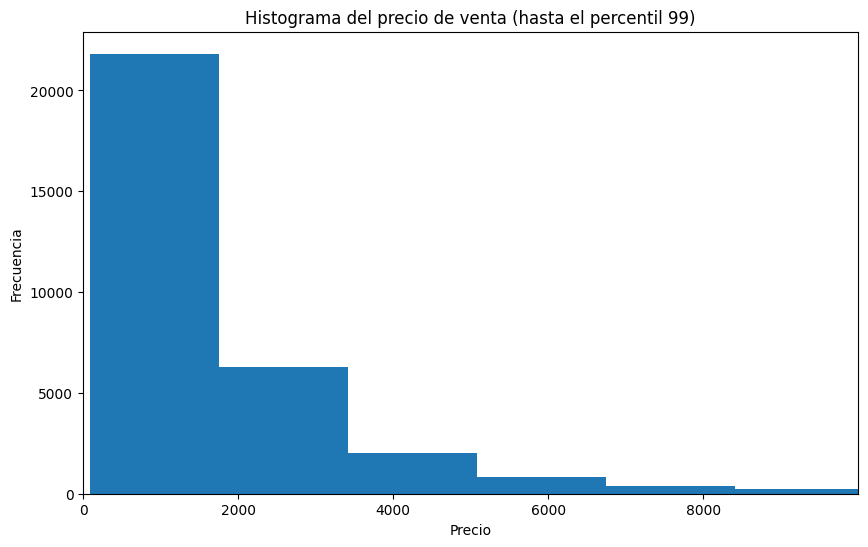

In [ ]:
#vamos a generar un histograma

import matplotlib.pyplot as plt

# Percentil 99
p99 = df["discount_price"].quantile(0.99) # La función quantile(0.99) nos permite calcular el valor por debajo del cual se encunetra el 99% de los precios.

plt.figure(figsize=(10,6))

plt.hist(df["discount_price"], bins=40)

plt.xlim(0, p99)

plt.title("Histograma del precio de venta (hasta el percentil 99)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

La grafica de distribucion de precios presenta una fuerte asimetría positiva.
Existe una cola larga hacia la derecha.
La mayor parte de los productos se concentra en precios bajos y medios.
Visualmente no parece compatible con una distribución Normal.

Diagrama de caja y bigotes

Después de analizar la distribución de frecuencias mediante el histograma, resulta conveniente complementar el análisis exploratorio utilizando un diagrama de caja y bigotes.

Mientras que el histograma permite observar la forma general de la distribución, el dagrama de caja y bigotes resume la información mediante medidas de posición y dispersión.

El diagrama caja y bigotes se utiliza para evaluar si los precios de los productos presentan una alta dispersión o valores excepcionalmente elevados, información que resulta relevante antes de proceder al ajuste de distribuciones probabilísticas.

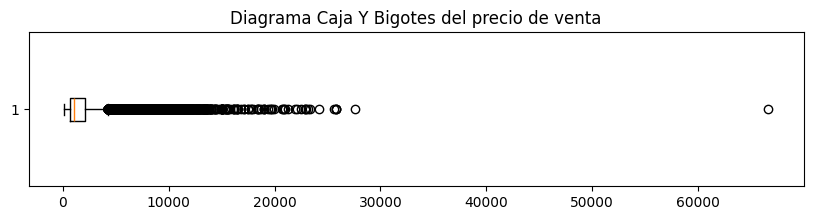

In [ ]:
plt.figure(figsize=(10,2))

plt.boxplot(df["discount_price"], vert=False)

plt.title("Diagrama Caja Y Bigotes del precio de venta")

plt.show()

Dado que la distribución original presenta una marcada asimetría positiva, una alternativa común en variables económicas es aplicar una transformación logarítmica.

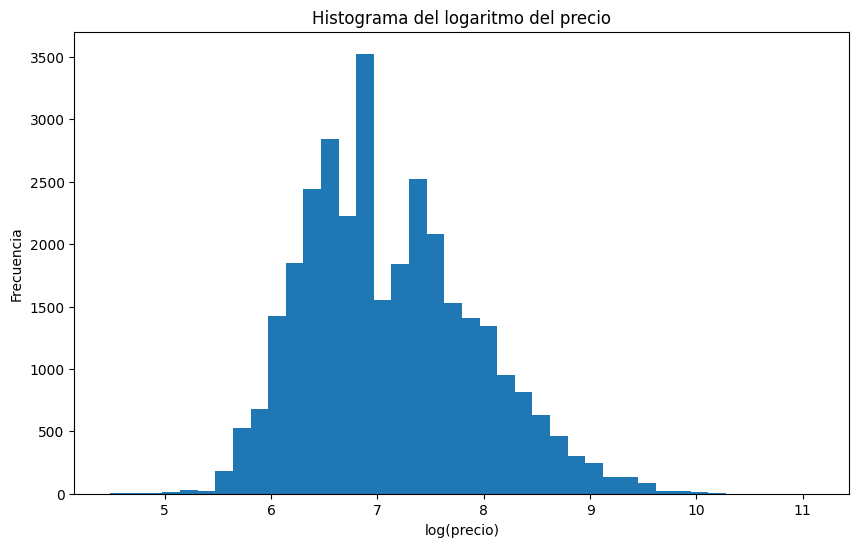

In [ ]:
##Graficamos el histograma utilizando el logartimo de los precios

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(np.log(df["discount_price"]), bins=40)

plt.title("Histograma del logaritmo del precio")
plt.xlabel("log(precio)")
plt.ylabel("Frecuencia")

plt.show()

La distribución es mucho más simétrica.
observamos una forma aproximadamente acampanada.
La cola derecha disminuye considerablemente.
Aunque aún existe una ligera asimetría, la forma es mucho más cercana a una Normal.

Eso es exactamente lo que esperaríamos si los precios siguieran una distribución Log-Normal.


#NOTA
El histograma de los precios originales muestra una marcada asimetría positiva, descartando visualmente un comportamiento normal.

Sin embargo, al aplicar una transformación logarítmica a los precios, la distribución adquiere una forma aproximadamente simétrica y cercana a la distribución Normal.

 Este comportamiento podría sugerir que la distribución Log-Normal podría proporcionar un mejor ajuste a los datos que la distribución Normal.

##Cuantil-Cuantil (QQ Plot)

##Qué es un cuantil?
En estadística, los cuantiles son puntos que dividen un conjunto de datos ordenados en partes iguales. De modo que un cuantil indica el valor por debajo del cual se encuentra un porcentaje de datos.

ref: https://www.probabilidadyestadistica.net/cuantiles/#%c2%bfque-son-los-cuantiles

Nosotros planteamos que con un grafico Cuantil-Cuantil (QQ Plot, *Quantile-Quantile Plot*) evaluaremos  si un conjunto de datos sigue aproximadamente una distribución teórica, siendo la distribución Normal la más utilizada.

El procedimiento consiste en comparar los cuantiles observados de la muestra con los cuantiles esperados de una distribución Normal. Si ambas distribuciones son similares, los puntos del gráfico tenderán a alinearse sobre una línea recta. En cambio, desviaciones sistemáticas respecto a dicha línea indican que los datos presentan diferencias con la distribución teórica, como asimetría, colas pesadas o valores atípicos.

aplicaremos el QQ sobre el **logaritmo del precio de venta** (`discount_price`), debido a que el histograma mostró una marcada asimetría positiva en los precios originales. Si el logaritmo de los precios presenta un comportamiento aproximadamente normal, ello constituirá una evidencia gráfica de que los precios podrían seguir una distribución **Log-Normal**, una de las distribuciones que posteriormente será ajustada mediante el método de Máxima Verosimilitud (MLE).


##Uso Gráfico Cuantil-Cuantil (QQ Plot)

El histograma de los precios mostró una marcada asimetría positiva y una cola larga hacia la derecha, lo que sugiere que la distribución Normal no describe adecuadamente el comportamiento de la variable. Dado que los precios son variables continuas y estrictamente positivas, una alternativa copodría ser  la distribución Log-Normal.

Una propiedad fundamental de la distribución Log-Normal establece que, si una variable aleatoria \(X\) sigue una distribución Log-Normal, entonces el logaritmo natural de dicha variable sigue una distribución Normal:

$$
X \sim \text{Log-Normal}
\Longleftrightarrow
\ln(X)\sim N(\mu,\sigma^2)
$$

Por esta razón, después de aplicar la transformación logarítmica a los precios, podríamos probar con  un gráfico Cuantil-Cuantil (QQ Plot).

Este gráfico compara los cuantiles observados del logaritmo de los precios con los cuantiles esperados de una distribución Normal. Si los puntos se alinean aproximadamente sobre una línea recta, existirá evidencia gráfica de que el logaritmo de los precios presenta un comportamiento cercano a la normalidad, reforzando la hipótesis de que los precios originales podrían seguir una distribución Log-Normal.

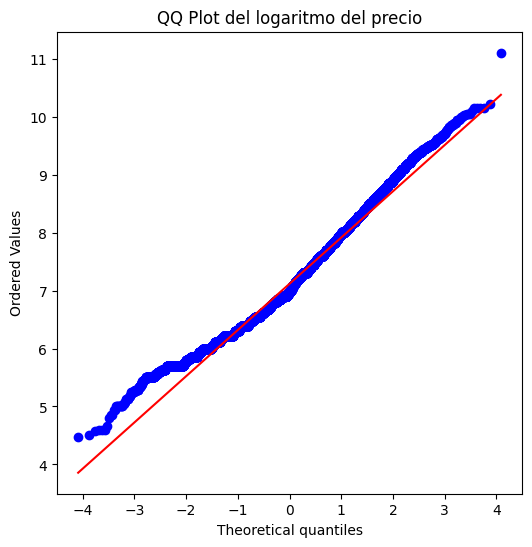

In [ ]:
 # Generarmos un QQ Plot del logaritmo de los precios con descuento y graficamos


import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

stats.probplot(np.log(df["discount_price"]), dist="norm", plot=plt)

plt.title("QQ Plot del logaritmo del precio")

plt.show()

El QQ-Plot del logaritmo de los precios muestra que la mayoría de las observaciones se alinean estrechamente con la recta de referencia, particularmente en la región central de la distribución. Esto indica que el logaritmo de los precios presenta un comportamiento aproximadamente normal. No obstante, se observan desviaciones en los cuantiles más bajos y más altos, especialmente en la cola superior, donde algunos valores se apartan de la recta debido a la presencia de precios excepcionalmente elevados. En conjunto, la evidencia gráfica respalda la hipótesis de que la distribución Log-Normal constituye una candidata adecuada para modelar los precios originales, aunque el ajuste no es perfectamente normal en los extremos.

#Inicio de ajuste cuantitativo de NORMAL/LOG NORMAL
El análisis exploratorio realizado en la sección anterior mostró que los precios originales presentan una marcada asimetría positiva, mientras que el logaritmo de los precios exhibe un comportamiento mucho más cercano a una distribución Normal.

Aunque esta evidencia gráfica sugiere que la distribución Log-Normal podría describir mejor los datos que la distribución Normal, resulta necesario verificar esta hipótesis mediante medidas cuantitativas de ajuste.

Para ello, en esta sección se ajustarán ambas distribuciones utilizando el método de Máxima Verosimilitud (Maximum Likelihood Estimation, MLE) y posteriormente se compararán empleando diferentes criterios estadísticos.

In [ ]:

## Realizamos el ajuste de las distribuciones Normal y Log-Normal a la variable discount_price mediante el método de Máxima Verosimilitud (MLE).
from scipy import stats
import numpy as np

# Ajuste Normal
mu_norm, sigma_norm = stats.norm.fit(df["discount_price"])

# Ajuste Log-Normal
shape_log, loc_log, scale_log = stats.lognorm.fit(
    df["discount_price"],
    floc=0
)

print("Normal")
print(mu_norm, sigma_norm)

print("\nLog-Normal")
print(shape_log, loc_log, scale_log)

Normal
1775.2665238528368 1975.132909634779

Log-Normal
0.80576023149944 0 1234.8567894216717


In [ ]:
# Calculamos la log-verosimilitud de las distribuciones Normal y Log-Normal para comparar su ajuste a los precios observados


loglik_normal = np.sum(
    stats.norm.logpdf(
        df["discount_price"],
        mu_norm,
        sigma_norm
    )
)

loglik_lognormal = np.sum(
    stats.lognorm.logpdf(
        df["discount_price"],
        shape_log,
        loc_log,
        scale_log
    )
)

print(loglik_normal)
print(loglik_lognormal)

-287180.68658538105
-265320.11563822563


| Criterio | Normal | Log-Normal | Mejor ajuste |
|:---------|:------:|:----------:|:------------:|
| Histograma | Asimétrica | Aproximadamente simétrica | Log-Normal |
| QQ Plot | No adecuado | Buen ajuste en la región central | Log-Normal |
| Log-verosimilitud | -287180.69 | -265320.12 | Log-Normal |

Los resultados muestran que la distribución Log-Normal proporciona un mejor ajuste que la distribución Normal. La evidencia gráfica indica que el logaritmo de los precios presenta un comportamiento cercano a la normalidad, mientras que la log-verosimilitud obtenida por la distribución Log-Normal (-265320.12) es mayor que la de la distribución Normal (-287180.6). En consecuencia, se descarta la distribución Normal como modelo principal y se selecciona la distribución Log-Normal como la mejor candidata hasta este punto del análisis, quedando pendiente su comparación con la distribución Gamma.

Hasta ahorita hemos visto que la distribucion que mejor se ajusta al precio es la log normal, sin embargo nos hace falta probar la distribución gamma para aseverar que es la mejor distribución, por eso nos plantearemos para la siguiente parte del proyecto:




**¿Qué distribución modela mejor los precios, la gamma o la Log-Normal?**

#LOG-NORMAL VS GAMMA

In [ ]:
## Ajustar una distribución Gamma a los precios con descuento mediante el método de Máxima Verosimilitud
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(
    df["discount_price"],
    floc=0
)

print(shape_gamma, loc_gamma, scale_gamma)

1.5226628482248312 0 1165.8959998416583


In [ ]:
# Calcular la log-verosimilitud de la distribución Gamma utilizando los parámetros estimados mediante MLE

loglik_gamma = np.sum(
    stats.gamma.logpdf(
        df["discount_price"],
        shape_gamma,
        loc_gamma,
        scale_gamma
    )
)

print(loglik_gamma)

-268906.20637625054


| Criterio | Log-Normal | Gamma | Mejor ajuste |
|:---------|-----------:|-------:|:------------:|
| Log-verosimilitud | -265320.12 | -268906.21 | Log-Normal |

A pesar de que la evidencia estadistica sigue favoreciendo a LOG-NORMAL, no conformes añadiremos otros criterios.

## Criterio de Información de Akaike (AIC)

El **Criterio de Información de Akaike (AIC)** es una medida utilizada para comparar modelos estadísticos considerando tanto la calidad del ajuste como la complejidad del modelo. Su objetivo es seleccionar el modelo que explique mejor los datos utilizando el menor número posible de parámetros.

Su expresión es:

$$
AIC = 2k - 2\ln(L)
$$

donde:

- $k$ es el número de parámetros del modelo.
- $L$ es la máxima verosimilitud del modelo ajustado.

Un modelo con muchos parámetros puede ajustarse mejor a los datos, pero también puede incurrir en sobreajuste. El AIC penaliza dicha complejidad, por lo que **el modelo con el menor valor de AIC se considera el más adecuado**.


## Criterio de Información Bayesiano (BIC)

El **Criterio de Información Bayesiano (BIC)** es similar al AIC, aunque aplica una penalización mayor a los modelos más complejos, especialmente cuando el tamaño de la muestra es grande.

Su expresión es:

$$
BIC = k\ln(n)-2\ln(L)
$$

donde:

- $k$ es el número de parámetros del modelo.
- $n$ es el número de observaciones.
- $L$ es la máxima verosimilitud.

Debido a que este estudio cuenta con una muestra de más de 31 mil observaciones, el BIC penaliza con mayor severidad los modelos innecesariamente complejos. Al igual que el AIC, **el modelo con el menor valor de BIC se considera el más conveniente**.


## Prueba de Kolmogorov--Smirnov (KS)

La **prueba de Kolmogorov--Smirnov (KS)** permite evaluar qué tan bien una distribución teórica representa los datos observados. A diferencia del AIC y el BIC, esta prueba no compara modelos entre sí, sino que compara la distribución acumulada empírica de los datos con la distribución acumulada teórica del modelo ajustado.

Las hipótesis de la prueba son:

$$
H_0:\ \text{Los datos siguen la distribución propuesta.}
$$

$$
H_a:\ \text{Los datos no siguen la distribución propuesta.}
$$

La prueba calcula la máxima diferencia entre ambas funciones de distribución acumulada y proporciona dos resultados:

- El **estadístico KS**, que mide la discrepancia máxima entre ambas distribuciones.
- El **valor-p**, utilizado para decidir si existe evidencia suficiente para rechazar la hipótesis nula.

Un estadístico KS pequeño y un valor-p elevado indican que la distribución propuesta es consistente con los datos observados.

In [ ]:
# ==========================
# Cálculo del AIC
# ==========================

# Número de parámetros del modelo
k = 2

# Criterio de Información de Akaike
AIC_lognormal = 2*k - 2*loglik_lognormal
AIC_gamma = 2*k - 2*loglik_gamma



# Cálculo del BIC


# Número de observaciones
n = len(df)

# Criterio de Información Bayesiano
BIC_lognormal = k*np.log(n) - 2*loglik_lognormal
BIC_gamma = k*np.log(n) - 2*loglik_gamma



# Prueba de Kolmogorov-Smirnov


# KS para la distribución Log-Normal
ks_lognormal = stats.kstest(
    df["discount_price"],
    "lognorm",
    args=(shape_log, loc_log, scale_log)
)

# KS para la distribución Gamma
ks_gamma = stats.kstest(
    df["discount_price"],
    "gamma",
    args=(shape_gamma, loc_gamma, scale_gamma)
)


# Resultados

print(f"AIC Log-Normal: {AIC_lognormal:.2f}")
print(f"AIC Gamma:      {AIC_gamma:.2f}")

print(f"BIC Log-Normal: {BIC_lognormal:.2f}")
print(f"BIC Gamma:      {BIC_gamma:.2f}")

print("\nLog-Normal")
print(ks_lognormal)

print("\nGamma")
print(ks_gamma)

AIC Log-Normal: 530644.23
AIC Gamma:      537816.41
BIC Log-Normal: 530660.97
BIC Gamma:      537833.15

Log-Normal
KstestResult(statistic=np.float64(0.08568561590710905), pvalue=np.float64(4.170837279561513e-204), statistic_location=np.float64(1000.0), statistic_sign=np.int8(1))

Gamma
KstestResult(statistic=np.float64(0.12420838519061667), pvalue=np.float64(0.0), statistic_location=np.float64(1000.0), statistic_sign=np.int8(1))


| Criterio | Log-Normal | Gamma | Mejor ajuste |
|:---------|-----------:|-------:|:------------:|
| Log-verosimilitud | -265320.12 | -268906.21 | Log-Normal |
| AIC | 530644.23 | 537816.41 | Log-Normal |
| BIC | 530660.97 | 537833.15 | Log-Normal |
| Estadístico KS | 0.08569 | 0.12421 | Log-Normal |
| Valor-p | $4.17\times10^{-204}$ | 0.00 | Log-Normal |

#DEFINICION DE INTERVALO DE CONFIANZA

Aunque los precios de los productos no siguen una distribución Normal, el tamaño de la muestra (n=31883) es suficientemente grande para aplicar el Teorema Central del Límite (TCL). Este establece que, para muestras grandes, la distribución de la media muestral se aproxima a una distribución Normal, independientemente de la distribución original de los datos.

Como la desviación estándar poblacional es desconocida, el intervalo de confianza para la media se construye utilizando la distribución *t* de Student:

$$
IC_{95\%}=\bar{x}\pm t_{\alpha/2,\;n-1}\left(\frac{s}{\sqrt{n}}\right)
$$

donde:

- $\bar{x}$ es la media muestral.
- $s$ es la desviación estándar muestral.
- $n$ es el tamaño de la muestra.
- $t_{\alpha/2,\;n-1}$ es el valor crítico de la distribución *t* de Student con $n-1$ grados de libertad.

En este estudio, el tamaño de la muestra es muy grande ($n=31\,883$), por lo que el valor crítico de la distribución *t* es prácticamente igual al de la distribución Normal estándar ($z\approx1.96$). En consecuencia, ambos intervalos de confianza son prácticamente idénticos.

In [ ]:
from scipy import stats
import numpy as np


# Intervalo de confianza del 95% para la media

# Estadísticos muestrales
n = len(df)
media = df["discount_price"].mean()
desv = df["discount_price"].std(ddof=1)   # Desviación estándar muestral
error_estandar = desv / np.sqrt(n)

# Valor crítico de t para un 95% de confianza
t_critico = stats.t.ppf(0.975, df=n-1)

# Intervalo de confianza
limite_inferior = media - t_critico * error_estandar
limite_superior = media + t_critico * error_estandar

# Resultados
print(f"Tamaño de la muestra: {n}")
print(f"Media muestral: {media:.2f}")
print(f"Desviación estándar: {desv:.2f}")
print(f"Error estándar: {error_estandar:.2f}")
print(f"Valor crítico t: {t_critico:.4f}")
print(f"IC 95%: ({limite_inferior:.2f}, {limite_superior:.2f})")

Tamaño de la muestra: 31883
Media muestral: 1775.27
Desviación estándar: 1975.16
Error estándar: 11.06
Valor crítico t: 1.9600
IC 95%: (1753.59, 1796.95)


Se construyó un intervalo de confianza del 95% para el precio medio de los productos utilizando la distribución t de Student. El intervalo obtenido fue (1753.59, 1796.95), lo que indica que, con un nivel de confianza del 95%, el precio promedio poblacional de los productos se encuentra dentro de este rango. Debido al gran tamaño de la muestra (n=31883), el intervalo es relativamente estrecho, lo que proporciona una estimación precisa de la media poblacional

##¿Difiere el precio medio entre categorías?

Actualmente ya solo nos falta responder a la siguiente pregunta planteada en los objetivos: ¿Difiere el precio medio entre categorías?


para esto haremos una prueba de hipótesis para comparar el precio promedio entre las tres categorías (Sports Shoes, Running y Casual Shoes).



## Prueba de hipótesis: Comparación del precio medio entre categorías


Las hipótesis planteadas son:

$$
H_0:\mu_1=\mu_2=\mu_3
$$

es decir, el precio promedio es igual en todas las categorías.

La hipótesis alternativa es:

$$
H_a:\text{Al menos una de las medias difiere.}
$$

La decisión se toma con un nivel de significancia de

$$
\alpha=0.05.
$$

Si el valor-p es menor que 0.05, se rechaza la hipótesis nula y se concluye que existen diferencias significativas entre al menos dos categorías.

In [ ]:
from scipy import stats


# Separar los precios por categoría
sports = df[df["category"] == "Sports Shoes"]["discount_price"]
running = df[df["category"] == "Running"]["discount_price"]
casual = df[df["category"] == "Casual Shoes"]["discount_price"]

# Aplicar ANOVA
F, p = stats.f_oneway(sports, running, casual)

print(f"Estadístico F: {F:.4f}")
print(f"Valor-p: {p:.6f}")

Estadístico F: 97.0378
Valor-p: 0.000000


### Interpretación

Se aplicó un análisis de varianza (ANOVA) para comparar el precio promedio entre las categorías **Sports Shoes**, **Running** y **Casual Shoes**. El análisis produjo un estadístico

$$
F = 97.04
$$

y un valor-p

$$
p < 0.001.
$$

Dado que el valor-p es inferior al nivel de significancia de

$$
\alpha = 0.05,
$$

se rechaza la hipótesis nula de igualdad de medias. En consecuencia, concluimos  que **al menos una de las categorías presenta un precio promedio diferente**.

qué categorías difieren entre sí

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df["discount_price"],
    groups=df["category"],
    alpha=0.05
)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2    meandiff p-adj   lower      upper   reject
--------------------------------------------------------------------
Casual Shoes      Running -845.202   0.0 -1008.1661 -682.2379   True
Casual Shoes Sports Shoes 106.3376   0.0    53.9398  158.7354   True
     Running Sports Shoes 951.5396   0.0   788.5974 1114.4817   True
--------------------------------------------------------------------


### Interpretación

Con el fin de identificar cuáles categorías presentan diferencias en su precio promedio, se aplicó la prueba de comparaciones múltiples de Tukey (Tukey HSD) con un nivel de significancia de $\alpha=0.05$.

Los resultados muestran que todas las comparaciones por pares presentan valores-p ajustados inferiores a 0.05, por lo que se rechaza la hipótesis nula de igualdad de medias en cada caso. En consecuencia, existen diferencias estadísticamente significativas entre las categorías **Casual Shoes**, **Running** y **Sports Shoes**.

En particular, la categoría **Running** presenta un precio promedio significativamente menor que **Casual Shoes** y **Sports Shoes**, mientras que **Sports Shoes** presenta un precio promedio significativamente mayor que las otras dos categorías. Asimismo, aunque la diferencia entre **Casual Shoes** y **Sports Shoes** es menor en magnitud, también resulta estadísticamente significativa.

# Conclusiones

Concluyendo con el analisis podemos decir que los precios con descuento presentan una marcada asimetría positiva, una elevada dispersión y la presencia de valores extremos en la cola derecha. Estas características indican que la distribución Normal no describe adecuadamente el comportamiento de los datos. En cambio, al aplicar la transformación logarítmica, la distribución presentó un comportamiento más cercano a la normalidad, lo que proporcionó evidencia inicial a favor de un posible ajuste Log-Normal.

Posteriormente, se estimaron mediante el método de Máxima Verosimilitud (MLE) los parámetros de las distribuciones Normal, Log-Normal y Gamma. La comparación mediante la log-verosimilitud, los criterios de información AIC y BIC y el estadístico de la prueba de Kolmogorov-Smirnov mostró de manera consistente que la distribución **Log-Normal** ofrece el mejor ajuste relativo entre los modelos evaluados.

Aunque la prueba de Kolmogorov-Smirnov rechazó formalmente el ajuste de las tres distribuciones, este resultado debe interpretarse considerando el gran tamaño de la muestra, ya que con un número elevado de observaciones la prueba puede detectar incluso diferencias pequeñas entre la distribución empírica y la teórica. A pesar de ello, la distribución Log-Normal obtuvo el menor estadístico de Kolmogorov-Smirnov, por lo que fue la que presentó la menor discrepancia respecto a los datos observados.

También se construyó un intervalo de confianza del 95 % para el precio medio, obteniéndose el intervalo **(1753.59, 1796.95)**. Bajo los supuestos del procedimiento utilizado, se estima con un nivel de confianza del 95 % que la media poblacional del precio con descuento se encuentra dentro de dicho rango.

Para determinar si el precio promedio varía entre las categorías **Sports Shoes**, **Running** y **Casual Shoes**, se aplicó un análisis de varianza de una vía. Los resultados mostraron diferencias estadísticamente significativas entre las medias de las categorías, con un estadístico (F=97.04) y un valor (p<0.001). Por lo tanto, se rechazó la hipótesis nula de igualdad de medias.

Posteriormente, la prueba de comparaciones múltiples  mostró diferencias significativas en todas las comparaciones por pares. Esto indica que cada una de las categorías analizadas presenta un precio promedio estadísticamente diferente al de las demás.

En respuesta a las preguntas planteadas al inicio del proyecto, se concluye que la distribución **Log-Normal es la que mejor representa los precios de los productos entre las tres alternativas analizadas**, debido a que presentó el mejor desempeño en el analisis tanto teorico como visual. Asimismo, se encontró evidencia suficiente para concluir que el precio medio difiere significativamente entre las categorías, por lo que la categoría del calzado se encuentra asociada con diferencias en el nivel promedio de precios.
